In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("data/processed_esg_financial_data.csv")

df.columns = df.columns.str.lower()
df.head(20)

,company_id,company_name,industry,region,year,revenue,profit_margin,market_cap,growth_rate,esg_overall,...,esg_governance,carbon_emissions,water_usage,energy_consumption,growth_rate_lag1,revenue_lag1,profit_margin_lag1,revenue_growth,profit_trend,year_normalized
0,1,Company_1,Retail,Latin America,2015,0.002342,0.371429,0.000388,0.552703,0.548108,...,0.768,0.000193,0.000321,0.000038,NaN,NaN,NaN,NaN,NaN,0
1,1,Company_1,Retail,Latin America,2016,0.002422,0.351429,0.000422,0.529730,0.544865,...,0.785,0.000203,0.000338,0.000040,0.552703,0.002342,0.371429,0.034491,-0.020000,1
2,1,Company_1,Retail,Latin America,2017,0.002926,0.360000,0.000360,0.745946,0.542703,...,0.778,0.000247,0.000411,0.000049,0.529730,0.002422,0.351429,0.208038,0.008571,2
3,1,Company_1,Retail,Latin America,2018,0.002890,0.347143,0.000325,0.471622,0.558919,...,0.783,0.000233,0.000389,0.000046,0.745946,0.002926,0.360000,-0.012287,-0.012857,3
4,1,Company_1,Retail,Latin America,2019,0.002869,0.355714,0.000620,0.477027,0.543784,...,0.761,0.000228,0.000381,0.000045,0.471622,0.002890,0.347143,-0.007464,0.008571,4
5,1,Company_1,Retail,Latin America,2020,0.002941,0.371429,0.000442,0.517568,0.534054,...,0.735,0.000231,0.000385,0.000046,0.477027,0.002869,0.355714,0.025067,0.015714,5
6,1,Company_1,Retail,Latin America,2021,0.003144,0.360000,0.000552,0.574324,0.532973,...,0.746,0.000243,0.000404,0.000048,0.517568,0.002941,0.371429,0.069037,-0.011429,6
7,1,Company_1,Retail,Latin America,2022,0.003083,0.345714,0.000285,0.462162,0.555676,...,0.769,0.000233,0.000388,0.000046,0.574324,0.003144,0.360000,-0.019356,-0.014286,7
8,1,Company_1,Retail,Latin America,2023,0.003323,0.361429,0.000430,0.585135,0.556757,...,0.781,0.000252,0.000420,0.000050,0.462162,0.003083,0.345714,0.078055,0.015714,8
9,1,Company_1,Retail,Latin America,2024,0.003602,0.351429,0.000530,0.593243,0.564324,...,0.768,0.000271,0.000452,0.000054,0.585135,0.003323,0.361429,0.083722,-0.010000,9


In [17]:
print(df.columns)

Index(['company_id', 'company_name', 'industry', 'region', 'year', 'revenue',
       'profit_margin', 'market_cap', 'growth_rate', 'esg_overall',
       'esg_environmental', 'esg_social', 'esg_governance', 'carbon_emissions',
       'water_usage', 'energy_consumption', 'growth_rate_lag1', 'revenue_lag1',
       'profit_margin_lag1', 'revenue_growth', 'profit_trend',
       'year_normalized'],
      dtype='str')


In [18]:
df = df.sort_values(['company_id', 'year'])
df = df.reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   company_id          11000 non-null  int64  
 1   company_name        11000 non-null  str    
 2   industry            11000 non-null  str    
 3   region              11000 non-null  str    
 4   year                11000 non-null  int64  
 5   revenue             11000 non-null  float64
 6   profit_margin       11000 non-null  float64
 7   market_cap          11000 non-null  float64
 8   growth_rate         11000 non-null  float64
 9   esg_overall         11000 non-null  float64
 10  esg_environmental   11000 non-null  float64
 11  esg_social          11000 non-null  float64
 12  esg_governance      11000 non-null  float64
 13  carbon_emissions    11000 non-null  float64
 14  water_usage         11000 non-null  float64
 15  energy_consumption  11000 non-null  float64
 16  growth_rate_lag

In [19]:
# Lag Features (VERY IMPORTANT for prediction)
df['growth_rate_lag1'] = df.groupby('company_id')['growth_rate'].shift(1)
df['revenue_lag1'] = df.groupby('company_id')['revenue'].shift(1)
df['profit_margin_lag1'] = df.groupby('company_id')['profit_margin'].shift(1)
df.describe()

,company_id,year,revenue,profit_margin,market_cap,growth_rate,esg_overall,esg_environmental,esg_social,esg_governance,carbon_emissions,water_usage,energy_consumption,growth_rate_lag1,revenue_lag1,profit_margin_lag1,revenue_growth,profit_trend,year_normalized
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,11000.000000
mean,500.500000,2020.000000,0.025639,0.441435,0.015462,0.551847,0.522327,0.564170,0.556606,0.517677,0.007291,0.010703,0.006693,0.552160,0.024582,0.441628,0.049086,-0.000162,5.000000
std,288.688113,3.162421,0.055151,0.125124,0.046139,0.121435,0.171826,0.267672,0.233562,0.253234,0.029108,0.029977,0.029269,0.121029,0.051371,0.122773,0.098033,0.037958,3.162421
min,1.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000037,0.000000,-1.000000,-0.244286,0.000000
25%,250.750000,2017.000000,0.004994,0.361429,0.001267,0.478378,0.408649,0.347000,0.376000,0.307750,0.000694,0.001223,0.000173,0.479730,0.004917,0.362857,-0.013921,-0.021429,2.000000
50%,500.500000,2020.000000,0.010324,0.435714,0.003577,0.552703,0.522162,0.556000,0.551500,0.521000,0.001666,0.003884,0.000699,0.552703,0.010099,0.437143,0.050417,0.000000,5.000000
75%,750.250000,2023.000000,0.023824,0.518571,0.011550,0.625676,0.641081,0.790000,0.738000,0.730000,0.004243,0.010036,0.003223,0.625676,0.023040,0.517143,0.113813,0.021429,8.000000
max,1000.000000,2025.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.856498,1.000000,0.382702,0.275714,10.000000


In [20]:
# Trend Features
df['revenue_growth'] = df.groupby('company_id')['revenue'].pct_change()
df['profit_trend'] = df.groupby('company_id')['profit_margin'].diff()
df['year_normalized'] = df['year'] - df['year'].min()


In [21]:
#TODO ESG_E7 - Exploratory Data Analysis(EDA)
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]
print(df.columns.tolist())

['company_id', 'company_name', 'industry', 'region', 'year', 'revenue', 'profit_margin', 'market_cap', 'growth_rate', 'esg_overall', 'esg_environmental', 'esg_social', 'esg_governance', 'carbon_emissions', 'water_usage', 'energy_consumption', 'growth_rate_lag1', 'revenue_lag1', 'profit_margin_lag1', 'revenue_growth', 'profit_trend', 'year_normalized']


In [22]:
#TODO ESG_E7 - Exploratory Data Analysis(EDA)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
esg_cols = [
    'esg_environmental',
    'esg_social',
    'esg_governance'
]

Q1 = df[esg_cols].quantile(0.25)
Q3 = df[esg_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[esg_cols] < (Q1 - 1.5 * IQR)) | (df[esg_cols] > (Q3 + 1.5 * IQR))).sum()
outliers

esg_environmental    0
esg_social           0
esg_governance       0
dtype: int64

In [23]:
#TODO ESG_S8 - Univariate-Bivariate Analysis
skew_kurt = pd.DataFrame({
    'Skewness': df[esg_cols].skew(),
    'Kurtosis': df[esg_cols].kurtosis()
})

skew_kurt['Distribution_Type'] = np.where(skew_kurt['Skewness'] > 1, 'Highly Right Skewed',
                                  np.where(skew_kurt['Skewness'] < -1, 'Highly Left Skewed',
                                  'Moderate/Normal'))

skew_kurt

,Skewness,Kurtosis,Distribution_Type
esg_environmental,0.000174,-1.073793,Moderate/Normal
esg_social,-0.000831,-0.858883,Moderate/Normal
esg_governance,-0.030436,-1.052276,Moderate/Normal


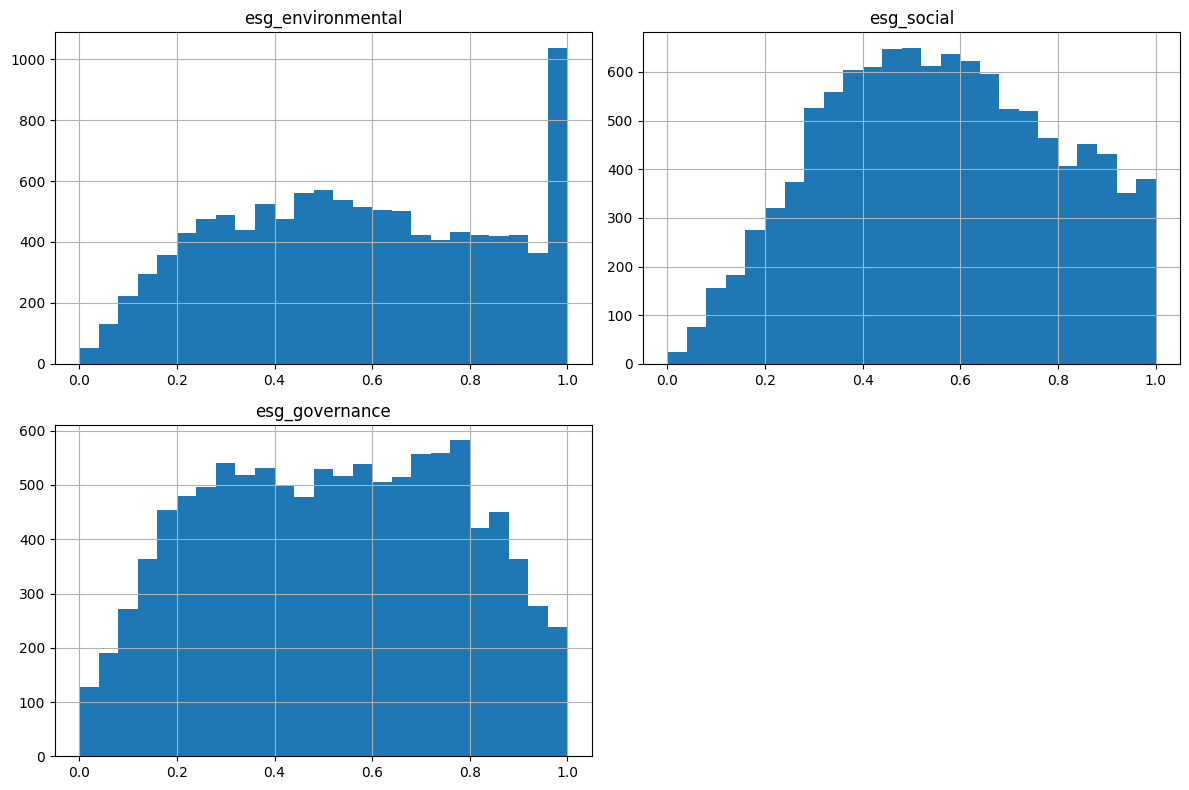

In [24]:
#TODO ESG_T12 - Plot histograms
df[esg_cols].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

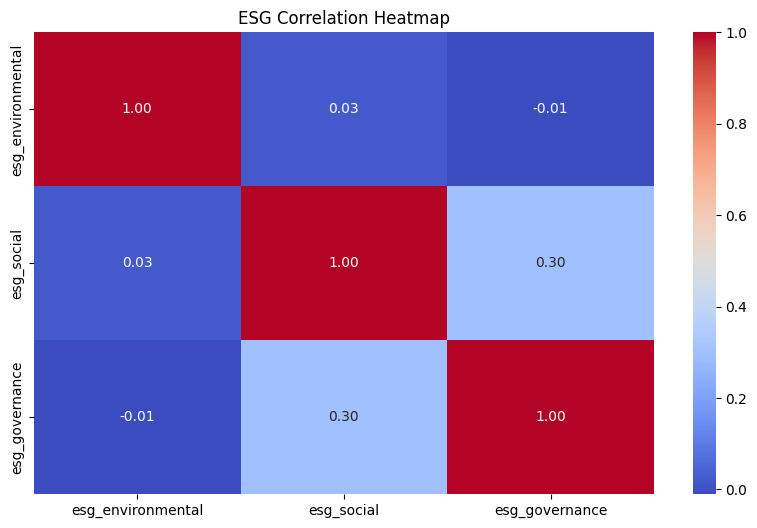

esg_environmental  esg_environmental    1.000000
esg_social         esg_governance       0.298431
esg_environmental  esg_social           0.025030
                   esg_governance      -0.010290
dtype: float64

In [25]:
#TODO ESG_S8 - Univariate-Bivariate Analysis
corr_matrix = df[esg_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("ESG Correlation Heatmap")
plt.show()

corr_matrix.unstack().sort_values(ascending=False).drop_duplicates().head(10)

In [26]:
#TODO ESG_S9 - Create ESG Index
weights = np.linspace(1, 2, len(esg_cols))
weights = weights / weights.sum()


In [27]:
df.to_csv("data/processed_esg_financial_data.csv", index=False)